In [122]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import scipy
import seaborn as sns

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.models import jacobian_aln as jac_aln

%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [146]:
aln = ALNModel()
C = aln.params.C

table_rate = aln.params.precalc_r
table_V = aln.params.precalc_V
table_tau = aln.params.precalc_tau_mu
mu_range = aln.params.Irange
sigma_range = aln.params.sigmarange
d_mu = aln.params.dI
d_sigma = aln.params.ds
print("mu range = ", mu_range[0], mu_range[-1], mu_range.shape, d_mu)
print("sigma range = ", sigma_range[0], sigma_range[-1], sigma_range.shape, d_sigma)
print("maximum rate = ", np.amax(table_rate))

n_xticks = 11
mu_ticklabels = np.zeros((n_xticks ))
mu_ticklabels[0:-1] = mu_range[0::int(len(mu_range) / (n_xticks - 1))]
mu_ticklabels[-1] = mu_range[-1]
n_yticks = 9
sigma_ticklabels = np.zeros((n_yticks ))
sigma_ticklabels[0:-1] = sigma_range[0::int(len(sigma_range) / (n_yticks - 1))]
sigma_ticklabels[-1] = sigma_range[-1]

mu range =  -1.0 7.0 (350,) 0.022922636103151817
sigma range =  0.5 5.0 (64,) 0.0714285714285714
maximum rate =  0.18094046744613917


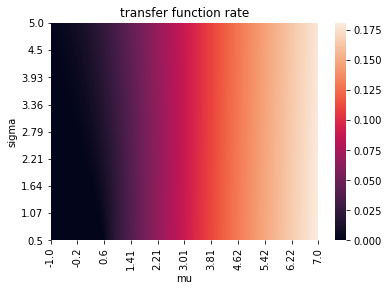

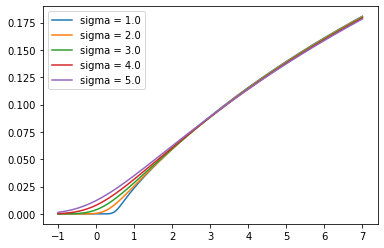

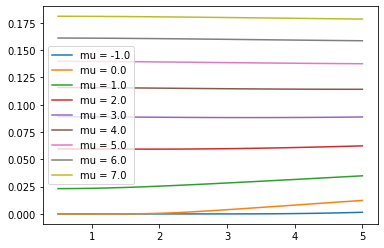

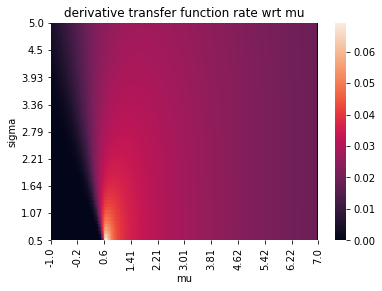

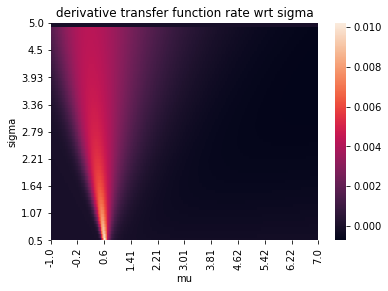

In [143]:
# heatmap rate transfer function
ax = sns.heatmap(table_rate.T)
ax.set(xlabel='mu', ylabel='sigma', title='transfer function rate')
ax.invert_yaxis()
ax.xaxis.set_major_locator(ticker.LinearLocator(n_xticks))
ax.set_xticklabels(np.round(mu_ticklabels,2))
ax.yaxis.set_major_locator(ticker.LinearLocator(n_yticks))
ax.set_yticklabels(np.round(sigma_ticklabels,2), rotation=0)
plt.show()

# plot over mu and sigma
sigma_list = np.arange(1., 6., 1.)
index_list_sigma = get_index_list(sigma_list, sigma_range)
plot_overMu(index_list_sigma, sigma_list, table_rate)

mu_list = np.arange(-1., 8., 1.)
index_list_mu = get_index_list(mu_list, mu_range)

plot_overSigma(index_list_mu, mu_list, table_rate)

# derivative
d_rate_dmu = d_dmu_table(table_rate)

ax = sns.heatmap(d_rate_dmu.T)
ax.set(xlabel='mu', ylabel='sigma', title='derivative transfer function rate wrt mu')
ax.invert_yaxis()
ax.xaxis.set_major_locator(ticker.LinearLocator(n_xticks))
ax.set_xticklabels(np.round(mu_ticklabels,2))
ax.yaxis.set_major_locator(ticker.LinearLocator(n_yticks))
ax.set_yticklabels(np.round(sigma_ticklabels,2), rotation=0)
plt.show()

d_rate_dsigma = d_dsigma_table(table_rate)

ax = sns.heatmap(d_rate_dsigma.T)
ax.set(xlabel='mu', ylabel='sigma', title='derivative transfer function rate wrt sigma')
ax.invert_yaxis()
ax.xaxis.set_major_locator(ticker.LinearLocator(n_xticks))
ax.set_xticklabels(np.round(mu_ticklabels,2))
ax.yaxis.set_major_locator(ticker.LinearLocator(n_yticks))
ax.set_yticklabels(np.round(sigma_ticklabels,2), rotation=0)
plt.show()

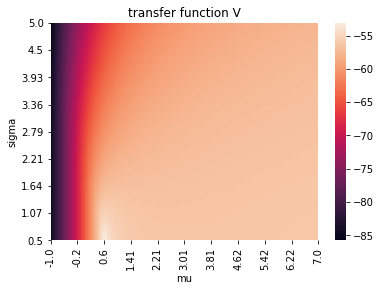

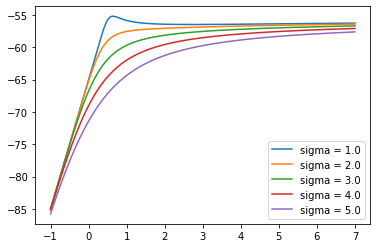

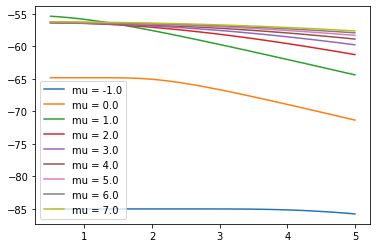

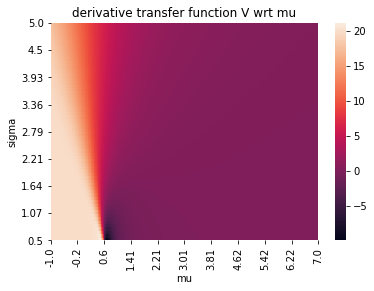

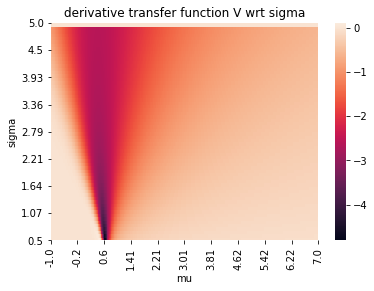

In [144]:
# heatmap V transfer function
ax = sns.heatmap(table_V.T)
ax.set(xlabel='mu', ylabel='sigma', title='transfer function V')
ax.invert_yaxis()
ax.xaxis.set_major_locator(ticker.LinearLocator(n_xticks))
ax.set_xticklabels(np.round(mu_ticklabels,2))
ax.yaxis.set_major_locator(ticker.LinearLocator(n_yticks))
ax.set_yticklabels(np.round(sigma_ticklabels,2), rotation=0)
plt.show()

# plot over mu and sigma
sigma_list = np.arange(1., 6., 1.)
index_list_sigma = get_index_list(sigma_list, sigma_range)
plot_overMu(index_list_sigma, sigma_list, table_V)

mu_list = np.arange(-1., 8., 1.)
index_list_mu = get_index_list(mu_list, mu_range)

plot_overSigma(index_list_mu, mu_list, table_V)

# derivative
d_V_dmu = d_dmu_table(table_V)

ax = sns.heatmap(d_V_dmu.T)
ax.set(xlabel='mu', ylabel='sigma', title='derivative transfer function V wrt mu')
ax.invert_yaxis()
ax.xaxis.set_major_locator(ticker.LinearLocator(n_xticks))
ax.set_xticklabels(np.round(mu_ticklabels,2))
ax.yaxis.set_major_locator(ticker.LinearLocator(n_yticks))
ax.set_yticklabels(np.round(sigma_ticklabels,2), rotation=0)
plt.show()

d_V_dsigma = d_dsigma_table(table_V)

ax = sns.heatmap(d_V_dsigma.T)
ax.set(xlabel='mu', ylabel='sigma', title='derivative transfer function V wrt sigma')
ax.invert_yaxis()
ax.xaxis.set_major_locator(ticker.LinearLocator(n_xticks))
ax.set_xticklabels(np.round(mu_ticklabels,2))
ax.yaxis.set_major_locator(ticker.LinearLocator(n_yticks))
ax.set_yticklabels(np.round(sigma_ticklabels,2), rotation=0)
plt.show()

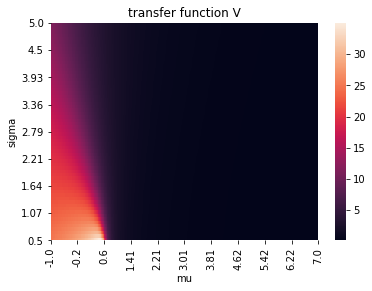

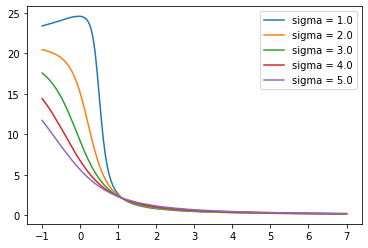

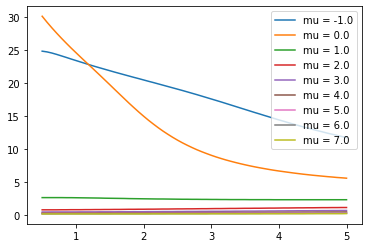

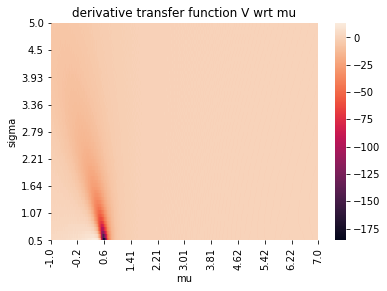

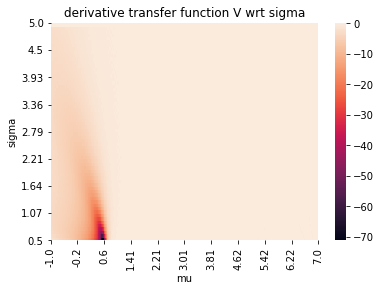

In [145]:
# heatmap tau transfer function
ax = sns.heatmap(table_tau.T)
ax.set(xlabel='mu', ylabel='sigma', title='transfer function V')
ax.invert_yaxis()
ax.xaxis.set_major_locator(ticker.LinearLocator(n_xticks))
ax.set_xticklabels(np.round(mu_ticklabels,2))
ax.yaxis.set_major_locator(ticker.LinearLocator(n_yticks))
ax.set_yticklabels(np.round(sigma_ticklabels,2), rotation=0)
plt.show()

# plot over mu and sigma
sigma_list = np.arange(1., 6., 1.)
index_list_sigma = get_index_list(sigma_list, sigma_range)
plot_overMu(index_list_sigma, sigma_list, table_tau)

mu_list = np.arange(-1., 8., 1.)
index_list_mu = get_index_list(mu_list, mu_range)

plot_overSigma(index_list_mu, mu_list, table_tau)

# derivative
d_tau_dmu = d_dmu_table(table_tau)

ax = sns.heatmap(d_tau_dmu.T)
ax.set(xlabel='mu', ylabel='sigma', title='derivative transfer function V wrt mu')
ax.invert_yaxis()
ax.xaxis.set_major_locator(ticker.LinearLocator(n_xticks))
ax.set_xticklabels(np.round(mu_ticklabels,2))
ax.yaxis.set_major_locator(ticker.LinearLocator(n_yticks))
ax.set_yticklabels(np.round(sigma_ticklabels,2), rotation=0)
plt.show()

d_tau_dsigma = d_dsigma_table(table_tau)

ax = sns.heatmap(d_tau_dsigma.T)
ax.set(xlabel='mu', ylabel='sigma', title='derivative transfer function V wrt sigma')
ax.invert_yaxis()
ax.xaxis.set_major_locator(ticker.LinearLocator(n_xticks))
ax.set_xticklabels(np.round(mu_ticklabels,2))
ax.yaxis.set_major_locator(ticker.LinearLocator(n_yticks))
ax.set_yticklabels(np.round(sigma_ticklabels,2), rotation=0)
plt.show()

In [109]:
def plot_overMu(sigmaindices, sigmavals, table_input):
    for i,s in zip(sigmaindices, sigmavals):
        plt.plot(mu_range, table_input[:,i], label= "sigma = {}".format(s))
    plt.legend()
    plt.show()
    
def plot_overSigma(muindices, muvals, table_input):
    for i,m in zip(muindices, muvals):
        plt.plot(sigma_range, table_input[i,:], label= "mu = {}".format(m))
    plt.legend()
    plt.show()
    
def get_index(val, range_):
    absolute_difference_function = lambda list_value : abs(list_value - val)
    closest_value = min(range_, key=absolute_difference_function)
    index = np.where( range_ == closest_value )[0][0]
    #print(index)
    return index
    
def get_index_list(vals, range_):
    return np.array( [get_index(v, range_) for v in vals])

In [141]:
def d_dmu(mu_, sigma_, table_):
    result = jac_aln.der_mu(sigma_, sigma_range, d_sigma, mu_, mu_range, d_mu, C, table_)
    return result

def d_dmu_table(table_):
    result = np.zeros(( table_.shape ))
    for m_ in range(len(mu_range)):
        for s_ in range(len(sigma_range)):
            result[m_,s_] = d_dmu(mu_range[m_], sigma_range[s_], table_)
    return result

def d_dsigma(mu_, sigma_, table_):
    result = jac_aln.der_sigma(sigma_, sigma_range, d_sigma, mu_, mu_range, d_mu, C, table_)
    return result

def d_dsigma_table(table_):
    result = np.zeros(( table_.shape ))
    for m_ in range(len(mu_range)):
        for s_ in range(len(sigma_range)):
            result[m_,s_] = d_dsigma(mu_range[m_], sigma_range[s_], table_)
    return result